<a href="https://colab.research.google.com/github/vijayavajrala463-ops/CV-lab-experiments/blob/main/cvlab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def show_comparision(original, equalized):
  plt.figure(figsize=(12, 10))

  # Original Image
  plt.subplot(2, 2, 1)
  plt.imshow(original, cmap="gray")
  plt.title('Original Image')
  plt.axis('off')

  # Histogram of Original Image
  plt.subplot(2, 2, 2)
  plt.hist(original.ravel(), 256, range=[0, 256], color="black")
  plt.title('Histogram (Original)')
  plt.xlabel('Intensity')
  plt.ylabel('Frequency')

  # Equalized Image
  plt.subplot(2, 2, 3)
  plt.imshow(equalized, cmap='gray')
  plt.title('Equalized Image')
  plt.axis('off')

  # Histogram of Equalized Image
  plt.subplot(2, 2, 4)
  plt.hist(equalized.ravel(), 256, range=[0, 256], color="black")
  plt.title('Histogram (Equalized)')
  plt.xlabel('Intensity')
  plt.ylabel('Frequency')

  plt.tight_layout()
  plt.show()

In [4]:
img=cv2.imread("/content/drive/MyDrive/dd/images.jpg")

In [5]:
def Histogram_Equalized(img):
  p=np.arrange(0,255)
  count=np.zeros(256)
  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      count[img[i][j]]+=1
      running_sum=np.zeros(256)
      max_value=max(count)
  for i in range(256):

      running_sum[i]=np.sum(count[:i+1])
  running_sum/=max_value
  running_sum*=255
  equalized_img=running_sum/(img)
  return equalized_img
        # show(equalized_img)

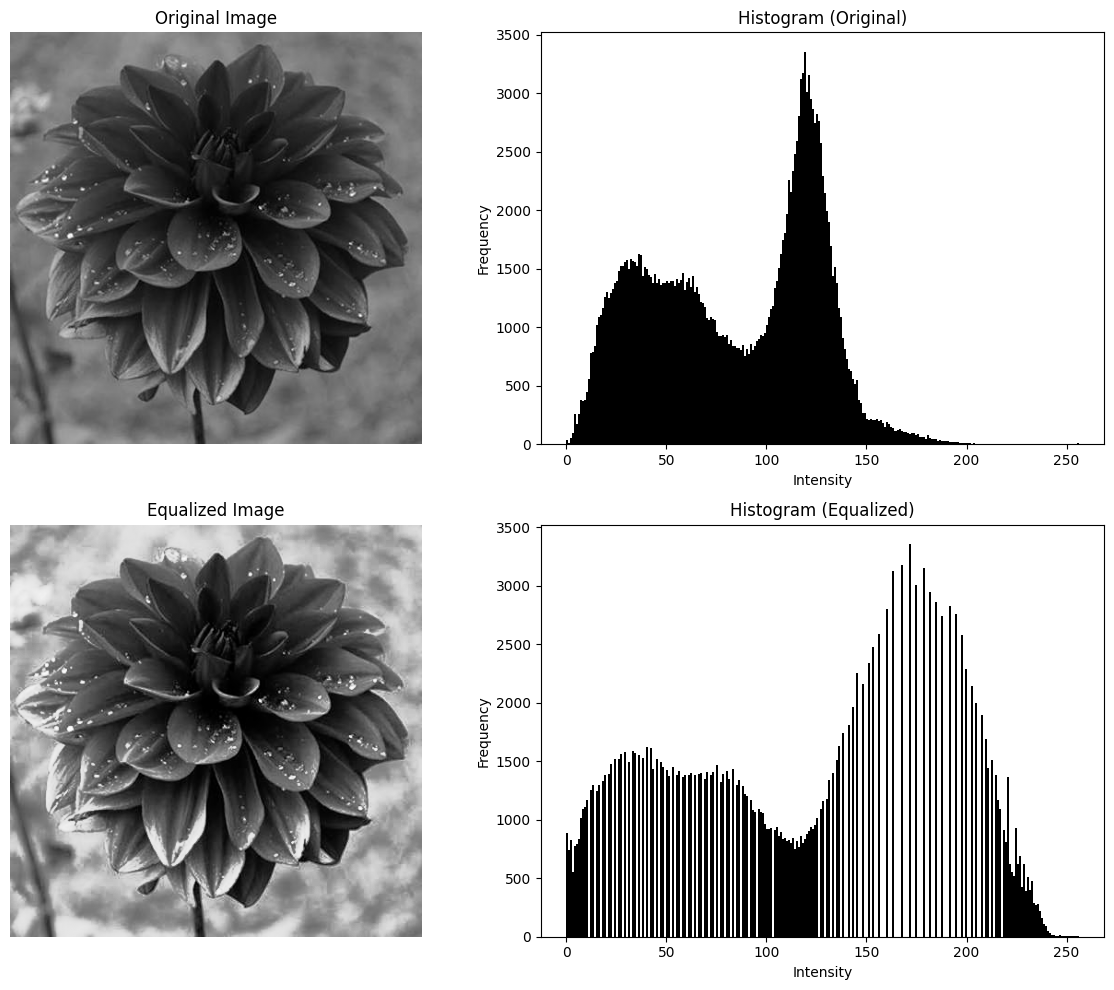

In [7]:
original = cv2.imread("/content/drive/MyDrive/dd/images.jpg",cv2.IMREAD_GRAYSCALE)
pixels=np.array(range(256))
for i in range(original.shape[0]):
  for j in range(original.shape[1]):
    pi=original[i,j]
    pixels[pi]+=1
  running_sum=np.zeros(len(pixels))
for i in range(len(pixels)):
  running_sum[i]=np.sum(pixels[:i+1])
max_value=np.max(running_sum)
running_sum/=max_value
running_sum*=255
running_sum=np.uint8(running_sum)
equalized = running_sum[original]
show_comparision(original,equalized)